In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import os
import quantecon as qe
from log_kde import log_kde
from pathlib import Path
from scipy.special import logsumexp
from scipy.linalg import expm
from sklearn.manifold import MDS 
from sklearn.decomposition import PCA 
from tqdm.notebook import tqdm

$$\log_{kde}(p) = \psi(p) = \log\left(\sum_{i=1}^N c_i \exp(-KL(p \;||\; P_{i, -}))\right)$$

In [2]:
def plot_projections(projections, time, molecule, MarkovChain):
    # color choices
    colors = {
        "benzene"     : "blue",
        "cyclohexane" : "green",
        "cyclooctane" : "red"
    }
    # plotting 
    for proj_name, proj in tqdm(projections, desc="Projection Set"):
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        ax.set_title(f"{molecule}: {proj_name} at t = {time}")

        # Scatter plot
        sc = ax.scatter(
            proj[:, 0],
            proj[:, 1],
            proj[:, 2],
            s=10,
            alpha=1,
            color=colors[molecule]
        )

        # labels
        ax.set_xlabel('Dim 1')
        ax.set_ylabel('Dim 2')
        ax.set_zlabel('Dim 3')
        for angle in (0, 30, 60, 90, 120, 180):
            ax.view_init(elev=30, azim=angle) 
            plt.savefig(f"plots/{molecule}/{MarkovChain}/time={time}/{proj_name} angle={angle}.png", dpi=150, bbox_inches="tight")

In [3]:
def generate_projections(times, molecule, MSM_csv, use_PTP):
    # load in stochastic matrix P
    P_ref = np.loadtxt(f"MarkovChains/{MSM_csv}", delimiter=",")
    P_ref = P_ref.astype("float64")

    # P^TP is a better input to demonstrate how things are connected
    if use_PTP:
        P_ref = np.matmul(P_ref, P_ref.T)
        P_ref = P_ref / P_ref.sum(axis=1, keepdims=True)

    # projection constructions objects
    pca = PCA(n_components=3)
    mds = MDS(n_components=3)

    for t in tqdm(times, desc="Time sets"):
        # make dir for time
        time_dir = f"plots/{molecule}/{Path(MSM_csv).stem}/time={t}"
        os.makedirs(time_dir, exist_ok=True)

        # build log_kde
        log_kde_obj = log_kde(P_ref, t)

        # generate R and Q matrices
        R_mat = log_kde_obj.calculate_R_mat()
        Q_mat = log_kde_obj.calculate_Q_mat()

        # build projections of for each variation
        projections = [
        ("PCA of R", pca.fit_transform(R_mat)),
        ("MDS of R", mds.fit_transform(R_mat)),
        ("PCA of Q", pca.fit_transform(Q_mat)),
        ("MDS of Q", mds.fit_transform(Q_mat)),
        ]

        # plot and save images
        plot_projections(projections, t, molecule, Path(MSM_csv).stem)  
    

Time sets:   0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:601: UserWarning: The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:601: UserWarning: The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:298

Projection Set:   0%|          | 0/4 [00:00<?, ?it/s]

Time sets:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

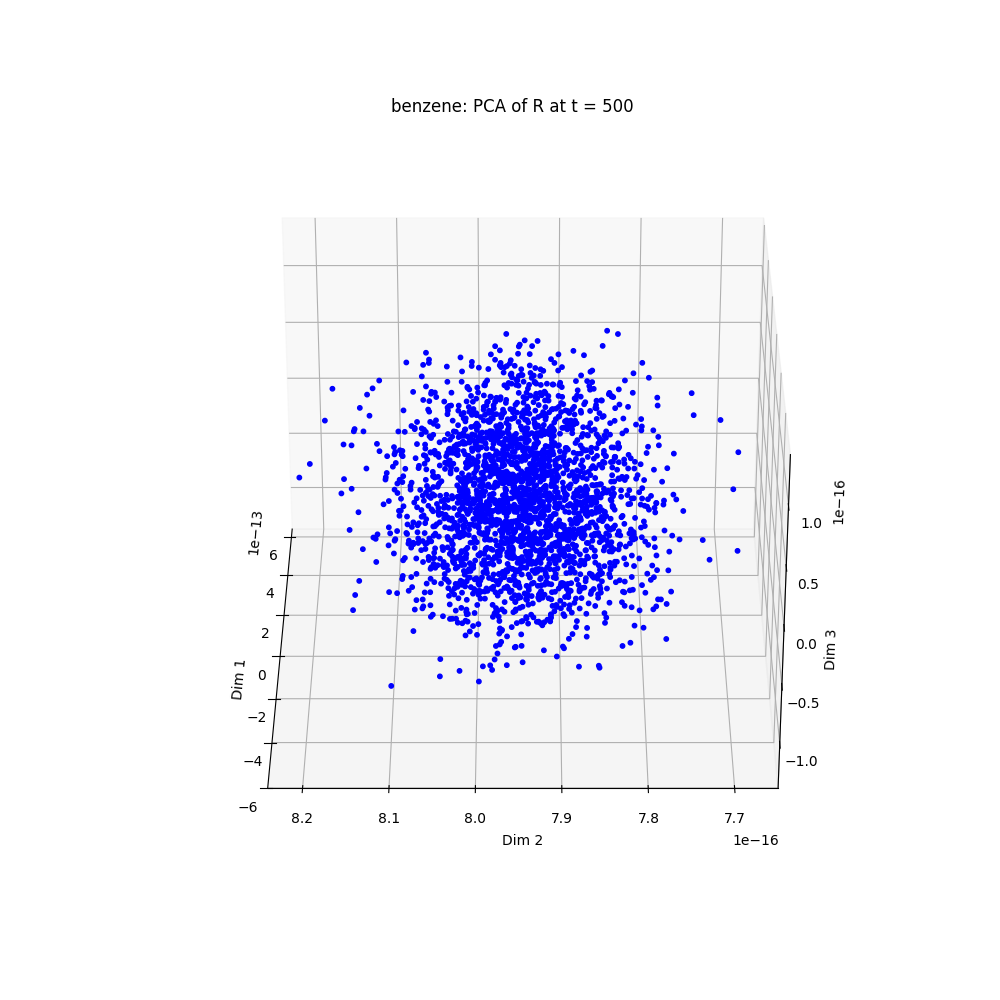

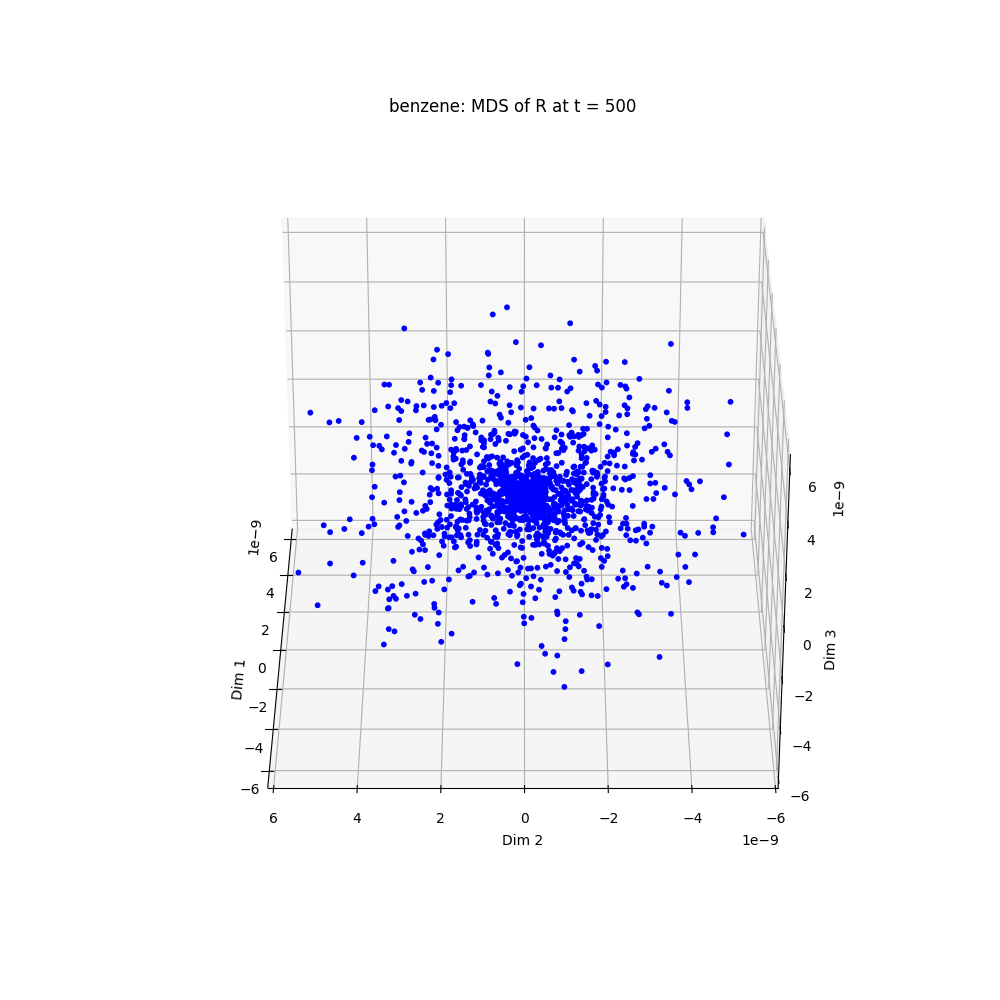

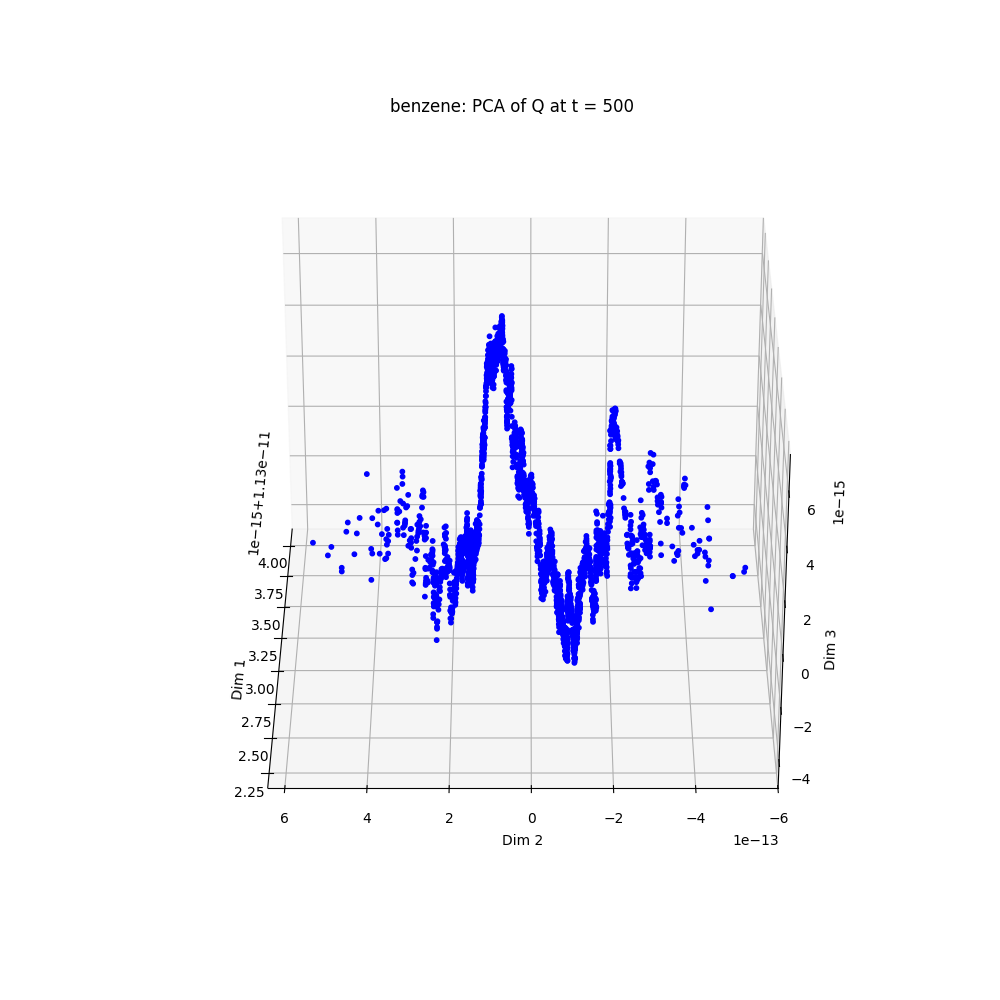

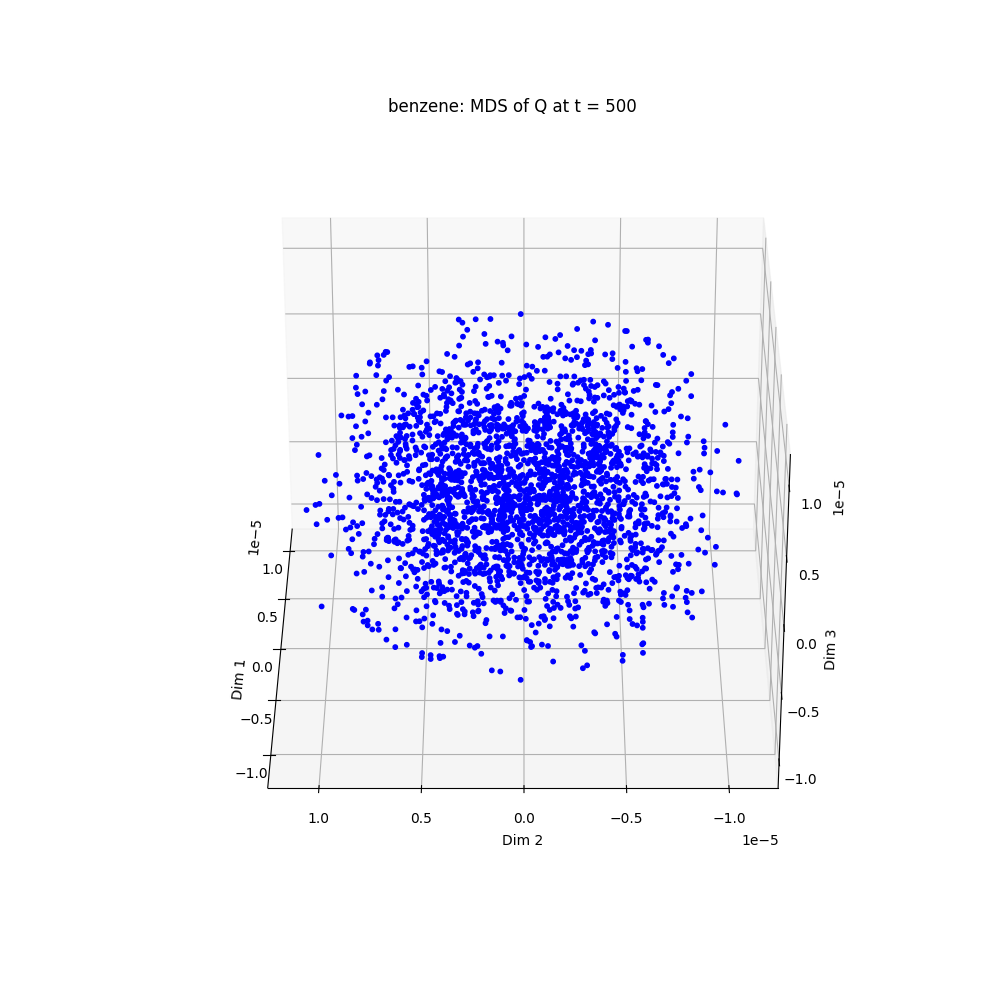

In [4]:
ts = [500]
projections = [("benzene", "P_matrix_benzene_R12_MSM2.csv"), 
               ("benzene", "P_matrix_benzene_R72_MSM2.csv"),
               ("cyclohexane", "P_matrix_cyclohexane_R12_MSM2.csv"),
               ("cyclohexane", "P_matrix_cyclohexane_R72_MSM2.csv"),
               ("cyclooctane", "P_matrix_cyclooctane_R18_MSM2.csv"),
               ("cyclooctane", "P_matrix_cyclooctane_R144_MSM2.csv")]
for proj in projections:
    generate_projections(times=ts, molecule=proj[0], MSM_csv=proj[1], use_PTP=False)